In [91]:
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import xml.etree.ElementTree as ET
import shapely
import cartopy
import pyproj
import numpy
from math import sin,cos,radians
from pathlib import Path

In [93]:
title = "Seduisant WNR Series 1 3/25/2026"
outfileBase = "Seduisant WNR Series 1 2026-03-25"
outputPath = "./output/Seduisant"

waypointFile = "./tracks/2020LakePontchartrainRacingMarks.gpx"
trackFile = "./tracks/2026-03-25 Seduisant.gpx"
windFile = "./windData/burl1_2026-04-11.pickle"
proj = cartopy.crs.Mercator()
buffer = 0.25 / 60 #buffer in nautical miles
figsize = (25,10)
nm2Meter = 1852.0
norm = mpl.colors.Normalize(vmin=5, vmax = 9, clip=True)
colorbarTicks = numpy.arange(norm.vmin,norm.vmax+0.001,1.0)
colorMap = mpl.cm.magma

majorMoveCuttoff = 15

In [94]:
Path(outputPath).mkdir(exist_ok=True,parents=True)

In [3]:
waypointXML = ET.parse(waypointFile)

In [4]:
wptList = []
for child in waypointXML.getroot():
    data = {
                'name':child.find('{http://www.topografix.com/GPX/1/1}name').text,
                'geometry':shapely.Point(child.attrib['lon'],child.attrib['lat'])
    }
    
    wptList.append(data)

waypointGdf = gpd.GeoDataFrame(data= pd.DataFrame.from_dict(wptList), geometry='geometry', crs='WGS84')

In [5]:
waypointGdf['name'] = waypointGdf['name'].str.replace('"','').str.replace('SYC ','')

In [6]:
trkXML = ET.parse(trackFile)

In [7]:
trkSegXML = trkXML.getroot().find('{http://www.topografix.com/GPX/1/1}trk').\
    find('{http://www.topografix.com/GPX/1/1}trkseg')

In [8]:
trkList = []
for child in trkSegXML:
    data = {
                'time':child.find('{http://www.topografix.com/GPX/1/1}time').text,
                'geometry':shapely.Point(child.attrib['lon'],child.attrib['lat'])
           }
    
    trkList.append(data)

trkGdf = gpd.GeoDataFrame(data=pd.DataFrame.from_dict(trkList), geometry='geometry', crs='WGS84')

In [9]:
trkGdf['time'] = pd.to_datetime( trkGdf['time'] ).dt.tz_convert('US/Central')
print(f"Start time {trkGdf['time'].min()}")

Start time 2026-03-25 18:40:01-05:00


In [10]:
trkGdf['timeDelta'] = trkGdf['time'] - trkGdf['time'].shift(1)
trkGdf['timeCumsum'] = trkGdf['timeDelta'].cumsum()
print(f"Mean time between measure {trkGdf['timeDelta'].mean()}")

Mean time between measure 0 days 00:00:08.179906


In [11]:
geod = pyproj.Geod(ellps='clrk66')
print(f"Total distance {geod.line_length(trkGdf['geometry'].x, trkGdf['geometry'].y) / nm2Meter}nm")

Total distance 6.458018489470264nm


In [12]:
trkGdf['bearing'] = geod.inv(trkGdf['geometry'].x,trkGdf['geometry'].y, trkGdf['geometry'].shift(1).x, trkGdf['geometry'].shift(1).y)[1]

In [13]:
mask = trkGdf['bearing'] < 0
trkGdf.loc[mask, 'bearing'] = trkGdf['bearing'][mask] + 360.0
trkGdf['majorMove'] = numpy.abs( trkGdf['bearing'] - trkGdf['bearing'].shift(2) ) > majorMoveCuttoff

In [14]:
trkGdf['delta_distance'] = numpy.nan
trkGdf.loc[1:,'delta_distance'] = geod.line_lengths(trkGdf['geometry'].x, trkGdf['geometry'].y) / nm2Meter

In [15]:
trkGdf['dist_cumsum'] = trkGdf['delta_distance'].cumsum()

In [16]:
trkGdf['delta_distance'].sum()

np.float64(6.458018489470264)

In [17]:
trkGdf['speed'] = (60.0 * 60.0 * trkGdf['delta_distance']) / trkGdf['timeDelta'].dt.total_seconds()

In [18]:
print(f"speed max:{trkGdf['speed'].max()}\tmin:{trkGdf['speed'].min()}\tmean:{trkGdf['speed'].mean()}")

speed max:8.564932155625439	min:3.7889328869408376	mean:6.653958514822466


In [19]:
dirArrowTimes = pd.date_range(start=trkGdf.loc[0,'time'], end=trkGdf.loc[trkGdf.index[-1],'time'], periods=7)[1:]

In [20]:
trkGdf.set_index('time',inplace=True)

In [21]:
trkGdf.head()

,geometry,timeDelta,timeCumsum,bearing,majorMove,delta_distance,dist_cumsum,speed
time,,,,,,,,
2026-03-25 18:40:01-05:00,POINT (-90.10379 30.03262),NaT,NaT,NaN,False,NaN,NaN,NaN
2026-03-25 18:40:09-05:00,POINT (-90.10368 30.03276),0 days 00:00:08,0 days 00:00:08,36.196285,False,0.009891,0.009891,4.450853
2026-03-25 18:40:13-05:00,POINT (-90.10358 30.03283),0 days 00:00:04,0 days 00:00:12,50.823435,False,0.006504,0.016395,5.853857
2026-03-25 18:40:19-05:00,POINT (-90.10344 30.03293),0 days 00:00:06,0 days 00:00:18,49.269116,False,0.009834,0.026229,5.900276
2026-03-25 18:40:32-05:00,POINT (-90.10313 30.03319),0 days 00:00:13,0 days 00:00:31,46.393108,False,0.022367,0.048596,6.194027


In [29]:
windDf = pd.read_pickle(windFile)
mask = numpy.logical_and( (windDf.index >= trkGdf.index.min()),\
                        windDf.index <= trkGdf.index.max())
windDf = windDf[mask].copy()
medianWind = windDf['WDIR'].median()
print(f"Median wind direction: {medianWind}")
windDf.head()

Median wind direction: 78.0


,#YY,MM,DD,hh,mm,WDIR,WSPD,GDR,GST,GTIME
2026-03-25 19:30:00-05:00,2026,3,25,19,30,87,3.6,999,99.0,9999
2026-03-25 19:20:00-05:00,2026,3,25,19,20,84,4.1,999,99.0,9999
2026-03-25 19:10:00-05:00,2026,3,25,19,10,78,4.1,999,99.0,9999
2026-03-25 19:00:00-05:00,2026,3,25,19,0,78,4.1,80,4.6,1804
2026-03-25 18:50:00-05:00,2026,3,25,18,50,77,4.1,999,99.0,9999


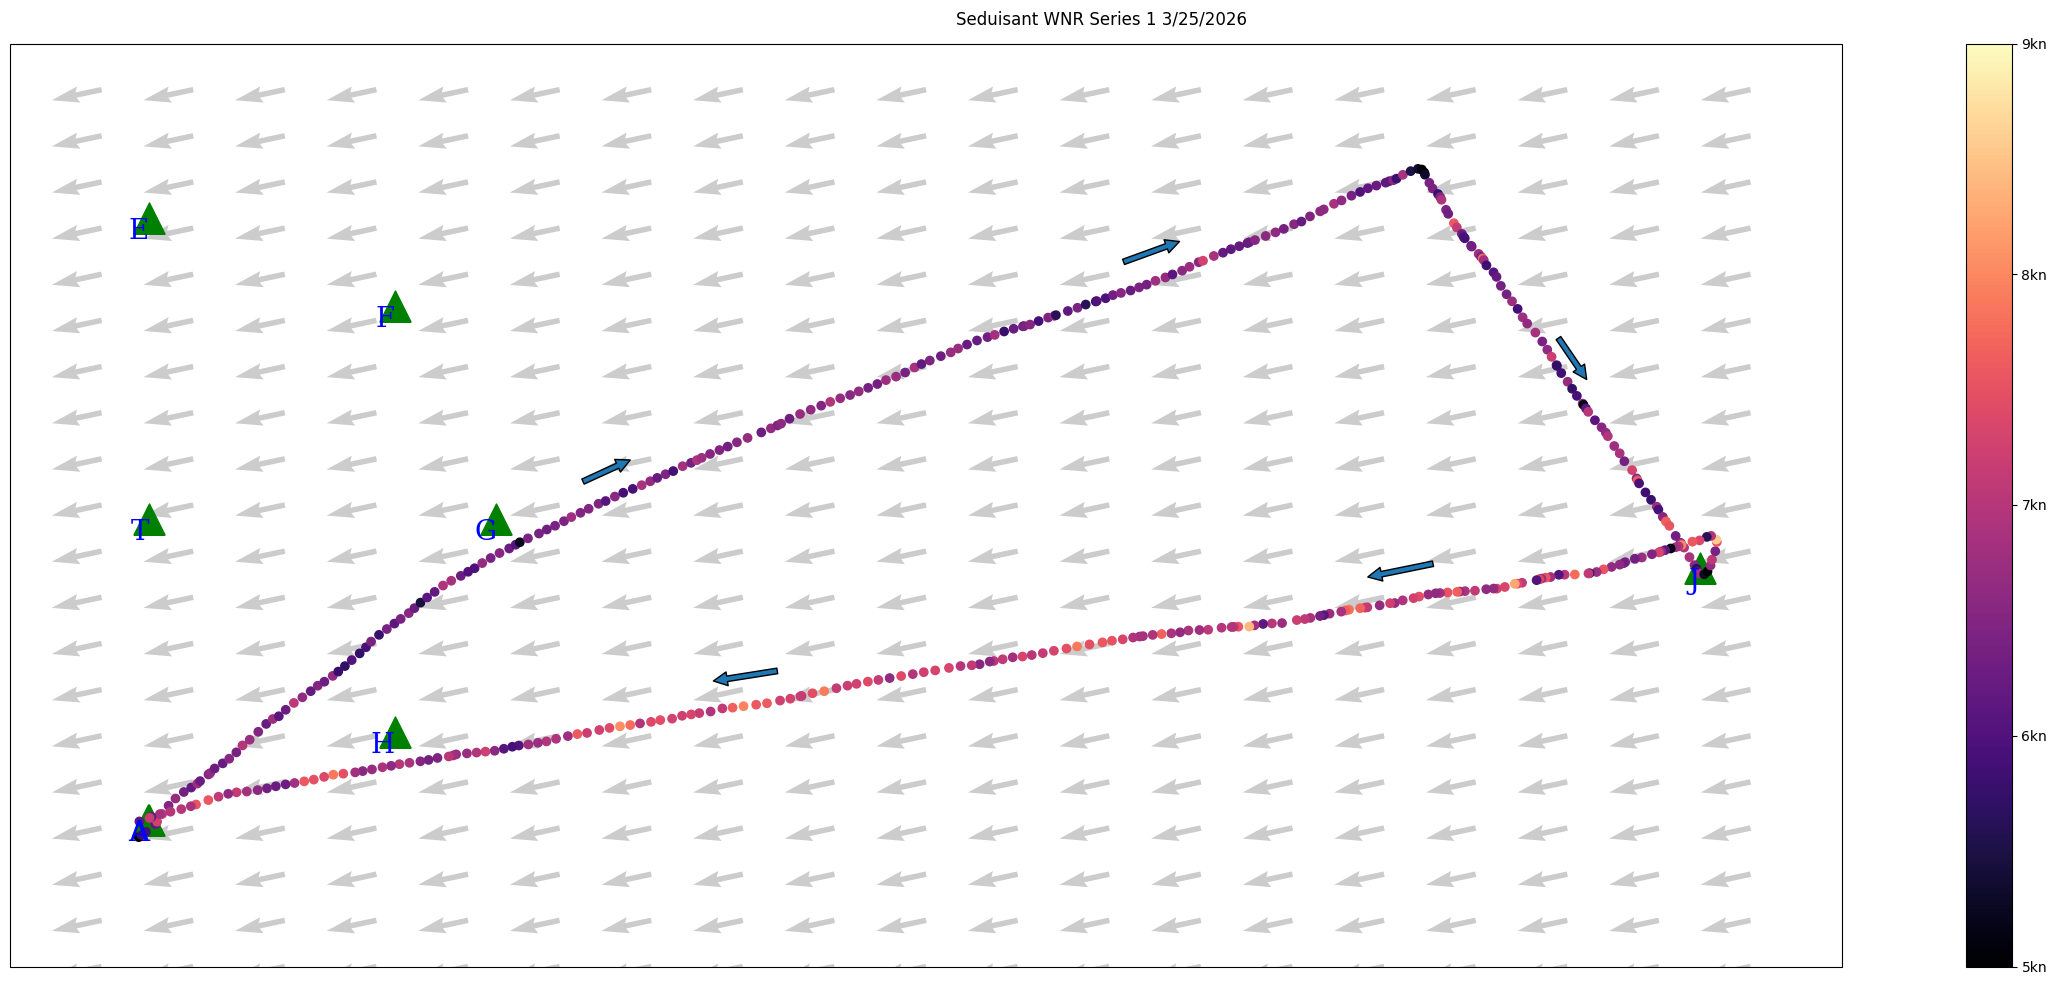

In [100]:
extent = trkGdf.total_bounds
boundBox = shapely.geometry.box(*extent)
wptMask = waypointGdf['geometry'].map(lambda pt: boundBox.contains(pt))

fig,ax = plt.subplots(1, figsize=figsize ,subplot_kw={'projection': proj})
fig.suptitle(title)

tmDelta = pd.Timedelta('1 minute')
for tm in dirArrowTimes:
    pt1 = trkGdf['geometry'].asof(tm)
    pt2 = trkGdf['geometry'].asof(tm+tmDelta)
    arrowBuffer = 0.001
    arrow = mpl.patches.FancyArrowPatch( (pt1.x, pt1.y+arrowBuffer), (pt2.x, pt2.y+arrowBuffer) ,mutation_scale=20, zorder=-1      )
    ax.add_patch(arrow)


ax.scatter(waypointGdf.geometry.x, waypointGdf.geometry.y, marker='^',s=500, c='g')

for idx,item in waypointGdf[wptMask].iterrows():
    ax.text(item['geometry'].x,item['geometry'].y,item['name'], va='top', ha='right', fontsize='20', fontname='serif',c='b' )

ax.set_xlim(extent[0]-buffer, extent[2]+buffer)
ax.set_ylim(extent[1]-buffer, extent[3]+buffer)
ax.coastlines()


trkPlt = ax.scatter(trkGdf.geometry.x,trkGdf.geometry.y, c=colorMap(norm(trkGdf['speed'])))

cax = fig.colorbar( plt.cm.ScalarMappable(norm=norm, cmap=colorMap), ax=ax)

cax.set_ticks(colorbarTicks)
cax.set_ticklabels( [f"{int(i)}kn" for i in colorbarTicks])

arrowRows = 20
axExtent = ax.get_extent()
lonMin = axExtent[0]
lonMax = axExtent[1]
lonRange = numpy.arange(lonMin,lonMax, (lonMax-lonMin)/arrowRows)
latMin = axExtent[2]
latMax = axExtent[3]
latRange = numpy.arange(latMin,latMax, (latMax-latMin)/arrowRows)

(lonMesh,latMesh) = numpy.meshgrid(lonRange, latRange)
ax.quiver(x=lonMesh,y=latMesh,\
          u=sin(radians(medianWind+180)),v=cos(radians(medianWind+180)),\
          angles='uv',\
          color =(0,0,0,0.2),
          zorder=-2)

fig.savefig(f"{outputPath}/{outfileBase}.jpg")

fig.tight_layout()

In [82]:
extent

array([-90.10378816,  30.03262368, -90.05121896,  30.05497218])

In [83]:
axExtent

(-90.10795482866666,
 -90.04705229333334,
 30.028457013333334,
 30.059138847666667)

In [45]:
centerPoint = shapely.geometry.box( *trkGdf.total_bounds ).centroid
centerPoint.xy

(array('d', [-90.077503561]), array('d', [30.043797930499995]))

In [51]:
sin(radians(medianWind))

0.9781476007338056

In [52]:
medianWind

np.float64(78.0)